In [16]:
#SIC contour 15% to matrix time x length contour - March 2024
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import seaborn as sns  # Optional for aesthetics
import datetime
import numpy as np

data_path  = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0/'
fig_path   = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_fig15/'
shape_path = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_shape15/'
shape_path2 = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_shape15_resample/'

In [19]:
#Load all
file_list = glob.glob(shape_path + '*.nc')
for i in np.arange(len(file_list)):
    ds1 = xr.open_dataset(file_list[i])
    dist = np.arange(len(ds1.C15x))

    # Add coordinate
    ds = xr.Dataset({'C15x': ('dist', ds1.C15x.data),
                     'C15y': ('dist', ds1.C15y.data)},
                    coords={'dist': dist
                           ,'time': ds1.time})
    #Resample
    ds_resampled = ds.interp(dist=np.arange(1000))
    ds_resampled.to_netcdf(shape_path2 + 'Contour15_'+ str(ds.time.data[0])[0:10] +'.nc')

In [19]:
ds = xr.open_mfdataset(shape_path2 + '*.nc')
ds.to_netcdf('/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_shape15_resample.nc')

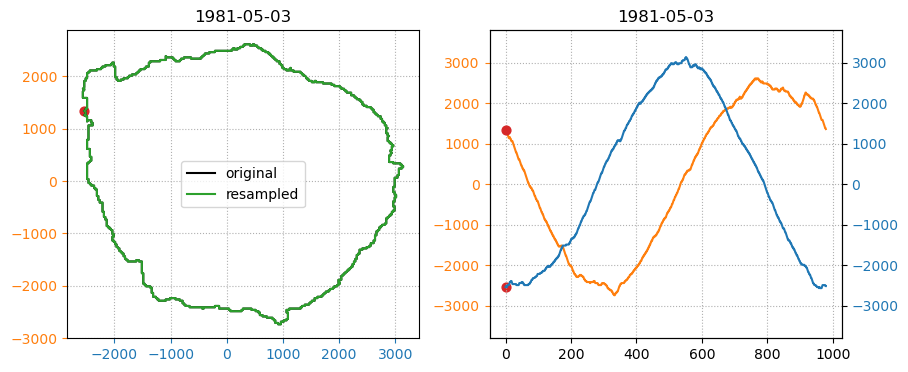

In [11]:
#Verif
fig, (ax1,ax2) = plt.subplots(1,2,figsize = (10,4))
ax1.plot(ds.C15x,ds.C15y,c = 'black',label = "original")
ax1.scatter(ds.C15x[0],ds.C15y[0],c = 'tab:red',s = 40)
ax1.set_title(str(ds.time.data[0])[0:10])
ax1.tick_params(axis='x', colors='tab:blue')
ax1.tick_params(axis='y', colors='tab:orange')

ax2.plot(ds.C15y, c='tab:orange')
ax2.scatter(0,ds.C15x[0],c = 'tab:red',s = 40)
ax2.set_title(str(ds.time.data[0])[0:10])
ax2.tick_params(axis='y', colors='tab:orange')

ax_right = ax2.twinx()  # instantiate a second axes that shares the same x-axis
ax_right.plot(ds.C15x, c='tab:blue')
ax_right.scatter(0,ds.C15y[0],c = 'tab:red',s = 40)
ax_right.tick_params(axis='y', labelcolor='tab:blue')

ny = 3800
ax2.set_ylim([-ny,ny])
ax_right.set_ylim([-ny,ny])

ax1.grid(linestyle = 'dotted')
ax2.grid(linestyle = 'dotted')
#plt.savefig('Contour_' + str(ds.time.data[0])[0:10] + '.png')
#plt.close()

ax1.plot(ds_resampled.C15x,ds_resampled.C15y,c = 'tab:green',label = "resampled")
ax1.legend()


In [ ]:
import numpy as np
from sklearn.decomposition import PCA

# Assuming you have vectors x and y
x = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])  # Example x vector
y = np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]])  # Example y vector

# Stack vectors horizontally
data = np.hstack((x, y))

# Instantiate PCA model
pca = PCA(n_components=2)  # Specify the number of principal components you want

# Fit PCA model
pca.fit(data)

# Transform data
transformed_data = pca.transform(data)

print("Original data shape:", data.shape)
print("Transformed data shape:", transformed_data.shape)
